<a href="https://colab.research.google.com/github/xiyuan1avery/ma2288/blob/main/notebooks/10_bootstrap_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
NUMBER_OF_BOOTSTRAPS = 10000

random.seed(SEED)
np.random.seed(SEED)

print("Bootstrap repetitions:", NUMBER_OF_BOOTSTRAPS)

Bootstrap repetitions: 10000


In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
DRIVE_DIRECTORY = Path(
    "/content/drive/MyDrive/ma2288_nextlat"
)

SAMPLE_RESULTS_PATH = (
    DRIVE_DIRECTORY
    / "results"
    / "tables"
    / "final_model_comparison_samples.csv"
)

print(
    "Sample results exist:",
    SAMPLE_RESULTS_PATH.exists(),
)

Sample results exist: True


In [4]:
sample_df = pd.read_csv(
    SAMPLE_RESULTS_PATH
)

print("Shape:", sample_df.shape)
print("Methods:", sample_df["method"].unique())
print("Horizons:", sorted(sample_df["horizon"].unique()))

print(
    sample_df.head().to_string(
        index=False
    )
)

Shape: (7200, 9)
Methods: ['Identity' 'One-step' 'Multi-step']
Horizons: [np.int64(1), np.int64(2), np.int64(4), np.int64(8), np.int64(16), np.int64(32)]
  method  horizon  sample_index  block_index  start_position  normalized_l2  cosine_similarity  output_kl  top1_agreement
Identity        1             0            0               0       0.541426           0.928034   5.493194             0.0
Identity        1             1            0               8       0.553905           0.900537  17.624285             0.0
Identity        1             2            0              16       0.433704           0.961723   3.456806             0.0
Identity        1             3            0              24       0.430362           0.969156   8.730706             0.0
Identity        1             4            0              31       0.234325           0.993157   2.451260             0.0


In [5]:
sample_counts = (
    sample_df
    .groupby(
        [
            "method",
            "horizon",
            "block_index",
        ]
    )
    .size()
)

print(sample_counts.describe())
print(
    "Unique samples per block:",
    sample_counts.unique(),
)

count    1440.0
mean        5.0
std         0.0
min         5.0
25%         5.0
50%         5.0
75%         5.0
max         5.0
dtype: float64
Unique samples per block: [5]


In [6]:
metrics = [
    "normalized_l2",
    "output_kl",
    "top1_agreement",
]

block_mean_df = (
    sample_df
    .groupby(
        [
            "method",
            "horizon",
            "block_index",
        ],
        as_index=False,
    )[metrics]
    .mean()
)

print("Block-level shape:", block_mean_df.shape)

print(
    block_mean_df.head().to_string(
        index=False
    )
)

Block-level shape: (1440, 6)
  method  horizon  block_index  normalized_l2  output_kl  top1_agreement
Identity        1            0       0.438744   7.551250             0.0
Identity        1            1       0.351950   3.893049             0.0
Identity        1            2       0.358688   4.775562             0.0
Identity        1            3       0.308347   3.019756             0.0
Identity        1            4       0.275413   5.264537             0.2


In [7]:
def paired_block_bootstrap(
    block_mean_df,
    horizon,
    metric,
    error_metric=True,
    number_of_bootstraps=10000,
    seed=42,
):
    """
    For error metrics:
        improvement = One-step - Multi-step

    For agreement metrics:
        improvement = Multi-step - One-step

    Positive values always mean Multi-step is better.
    """

    horizon_data = block_mean_df[
        block_mean_df["horizon"]
        == horizon
    ]

    pivot = horizon_data.pivot(
        index="block_index",
        columns="method",
        values=metric,
    ).dropna()

    if error_metric:
        block_differences = (
            pivot["One-step"]
            - pivot["Multi-step"]
        ).to_numpy()

    else:
        block_differences = (
            pivot["Multi-step"]
            - pivot["One-step"]
        ).to_numpy()

    rng = np.random.default_rng(seed)

    number_of_blocks = len(
        block_differences
    )

    bootstrap_means = np.empty(
        number_of_bootstraps
    )

    for bootstrap_index in range(
        number_of_bootstraps
    ):
        sampled_indices = rng.integers(
            low=0,
            high=number_of_blocks,
            size=number_of_blocks,
        )

        bootstrap_means[
            bootstrap_index
        ] = block_differences[
            sampled_indices
        ].mean()

    point_estimate = (
        block_differences.mean()
    )

    confidence_lower = np.percentile(
        bootstrap_means,
        2.5,
    )

    confidence_upper = np.percentile(
        bootstrap_means,
        97.5,
    )

    bootstrap_probability_positive = (
        bootstrap_means > 0
    ).mean()

    return {
        "point_estimate": point_estimate,
        "ci_lower": confidence_lower,
        "ci_upper": confidence_upper,
        "bootstrap_probability_positive": (
            bootstrap_probability_positive
        ),
        "number_of_blocks": number_of_blocks,
        "bootstrap_values": bootstrap_means,
    }

In [8]:
HORIZONS = [1, 2, 4, 8, 16, 32]

metric_settings = [
    (
        "normalized_l2",
        True,
        "Normalized L2 reduction",
    ),
    (
        "output_kl",
        True,
        "Output KL reduction",
    ),
    (
        "top1_agreement",
        False,
        "Top-1 agreement increase",
    ),
]

bootstrap_summary_rows = []
bootstrap_distributions = {}

for (
    metric,
    error_metric,
    display_name,
) in metric_settings:

    for horizon in HORIZONS:
        result = paired_block_bootstrap(
            block_mean_df=block_mean_df,
            horizon=horizon,
            metric=metric,
            error_metric=error_metric,
            number_of_bootstraps=(
                NUMBER_OF_BOOTSTRAPS
            ),
            seed=SEED + horizon,
        )

        bootstrap_summary_rows.append({
            "metric": metric,
            "metric_display_name": (
                display_name
            ),
            "horizon": horizon,
            "point_estimate": (
                result["point_estimate"]
            ),
            "ci_lower": (
                result["ci_lower"]
            ),
            "ci_upper": (
                result["ci_upper"]
            ),
            "bootstrap_probability_positive": (
                result[
                    "bootstrap_probability_positive"
                ]
            ),
            "number_of_blocks": (
                result["number_of_blocks"]
            ),
        })

        bootstrap_distributions[
            (metric, horizon)
        ] = result["bootstrap_values"]

bootstrap_summary_df = pd.DataFrame(
    bootstrap_summary_rows
)

In [9]:
print(
    bootstrap_summary_df.to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

        metric      metric_display_name  horizon  point_estimate  ci_lower  ci_upper  bootstrap_probability_positive  number_of_blocks
 normalized_l2  Normalized L2 reduction        1        0.003360  0.001447  0.005258                        0.999500                80
 normalized_l2  Normalized L2 reduction        2        0.001287 -0.002065  0.004297                        0.792600                80
 normalized_l2  Normalized L2 reduction        4        0.006669  0.002455  0.010827                        0.998800                80
 normalized_l2  Normalized L2 reduction        8        0.008357  0.001630  0.014216                        0.991300                80
 normalized_l2  Normalized L2 reduction       16        0.026416  0.020564  0.031673                        1.000000                80
 normalized_l2  Normalized L2 reduction       32        0.045117  0.038164  0.051838                        1.000000                80
     output_kl      Output KL reduction        1       

In [10]:
kl_bootstrap_df = (
    bootstrap_summary_df[
        bootstrap_summary_df["metric"]
        == "output_kl"
    ]
    .copy()
)

print(
    kl_bootstrap_df[
        [
            "horizon",
            "point_estimate",
            "ci_lower",
            "ci_upper",
            "bootstrap_probability_positive",
        ]
    ].to_string(
        index=False,
        float_format=lambda value: (
            f"{value:.6f}"
        ),
    )
)

 horizon  point_estimate  ci_lower  ci_upper  bootstrap_probability_positive
       1        0.017925  0.008020  0.027796                        0.999700
       2        0.034289  0.019747  0.048795                        1.000000
       4        0.085644  0.065668  0.105491                        1.000000
       8        0.152858  0.126877  0.178743                        1.000000
      16        0.428153  0.383668  0.474019                        1.000000
      32        1.401026  1.306025  1.504546                        1.000000


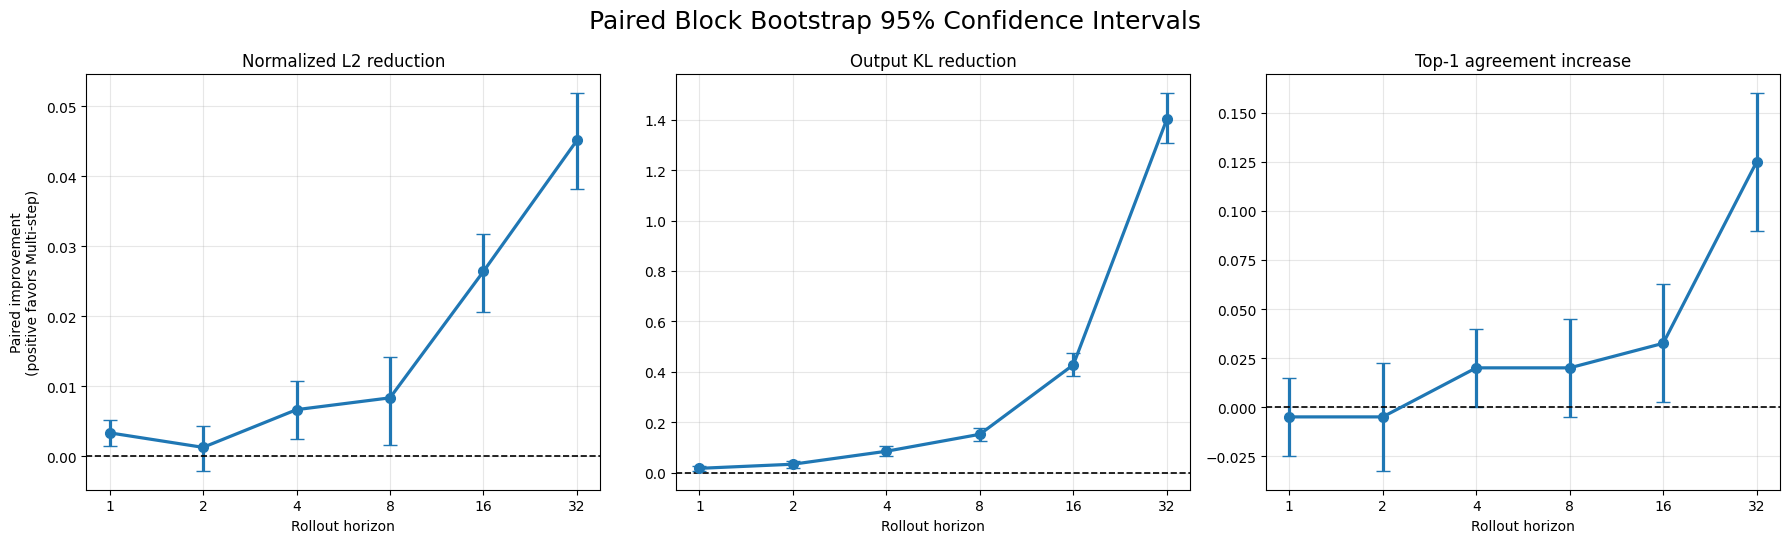

In [11]:
bootstrap_figure, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5.5),
)

for axis, (
    metric,
    error_metric,
    display_name,
) in zip(
    axes,
    metric_settings,
):
    metric_data = (
        bootstrap_summary_df[
            bootstrap_summary_df["metric"]
            == metric
        ]
        .sort_values("horizon")
    )

    lower_errors = (
        metric_data["point_estimate"]
        - metric_data["ci_lower"]
    )

    upper_errors = (
        metric_data["ci_upper"]
        - metric_data["point_estimate"]
    )

    axis.errorbar(
        metric_data["horizon"],
        metric_data["point_estimate"],
        yerr=[
            lower_errors,
            upper_errors,
        ],
        fmt="o-",
        linewidth=2.3,
        markersize=7,
        capsize=5,
    )

    axis.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.2,
    )

    axis.set_xscale(
        "log",
        base=2,
    )

    axis.set_xticks(HORIZONS)
    axis.set_xticklabels(HORIZONS)

    axis.set_xlabel(
        "Rollout horizon"
    )

    axis.set_title(display_name)
    axis.grid(alpha=0.3)

axes[0].set_ylabel(
    "Paired improvement\n"
    "(positive favors Multi-step)"
)

bootstrap_figure.suptitle(
    "Paired Block Bootstrap 95% Confidence Intervals",
    fontsize=18,
)

bootstrap_figure.tight_layout()
plt.show()

In [12]:
RESULT_DIRECTORY = (
    DRIVE_DIRECTORY
    / "results"
)

TABLE_DIRECTORY = (
    RESULT_DIRECTORY
    / "tables"
)

FIGURE_DIRECTORY = (
    RESULT_DIRECTORY
    / "figures"
)

TABLE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURE_DIRECTORY.mkdir(
    parents=True,
    exist_ok=True,
)

In [13]:
bootstrap_table_path = (
    TABLE_DIRECTORY
    / "bootstrap_confidence_intervals.csv"
)

bootstrap_figure_path = (
    FIGURE_DIRECTORY
    / "bootstrap_confidence_intervals.png"
)

bootstrap_summary_df.to_csv(
    bootstrap_table_path,
    index=False,
)

bootstrap_figure.savefig(
    bootstrap_figure_path,
    dpi=250,
    bbox_inches="tight",
)

print("Saved:", bootstrap_table_path)
print("Saved:", bootstrap_figure_path)

Saved: /content/drive/MyDrive/ma2288_nextlat/results/tables/bootstrap_confidence_intervals.csv
Saved: /content/drive/MyDrive/ma2288_nextlat/results/figures/bootstrap_confidence_intervals.png
